In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

In [2]:
# Read the mhd file from data
import os
import matplotlib.pyplot as plt

import mpl_interactions as pli
from gecco import patient_data
import gecco as fc
import numpy as np
from gecco.utils import nrrd_to_mhd, cropping_tool

## This script generates the rest of the code to run batch GECCO simulations

The first few cells are to check the simulation density and phantom are aligned, manually

Modify the dictionary so that the last integer specifies the right simulation to load for each of the simulations

## Running the GECCO sims

The last few cells generate the scripts for running the simulations

Best to make a test output directory with only 2 projections

From there create the full simulations

In [35]:
nrrd_files = {'0':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd',[1,0,2],[313,511,111,367,None,None],2],
            '1':['/media/jericho/T7/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd',[1,0,2],[200,300,111,367,None,None],8],
            '2':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd',[1,0,2],[287,511,2,392,15,78],2],
            '3':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd',[1,0,2],[254,None,None,None,None,None],1],
            '4':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd',[2,1,0],[None,114,None,None,None,None],1],
            '5':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd',[2,1,0],[None,72,None,None,None,None],1],
            '6':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd',[2,1,0],[None,70,None,None,None,None],None],
            '7':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd',[1,0,2],[367,None,None,None,None,None],None]}

In [36]:
file_index = '1'

## Load the simulation

In [37]:
nrrd_file = nrrd_files[file_index][0]
sim_num = nrrd_files[file_index][3]

In [42]:
phantom = patient_data.patient_phantom(nrrd_file, 1e10, reload=True, sim_num=None)

[2025-01-27 12:50:44,317] {patient_data.py:69} INFO - Reloading phantom
[2025-01-27 12:50:44,318] {patient_data.py:161} INFO - Found existing directory. Using mhd file Pelvis_Female_Patient_2_phantom.mhd
[2025-01-27 12:50:44,362] {patient_data.py:191} INFO - Phantom loaded from pickle file fastmc_1e06_10angles.pkl
[2025-01-27 12:50:44,390] {patient_data.py:197} INFO - Loading ggems files

[2025-01-27 12:50:44,391] {patient_data.py:228} INFO - Using the first detector layer ggems files
[2025-01-27 12:50:44,632] {patient_data.py:266} INFO - ggems files loaded
[2025-01-27 12:50:44,633] {patient_data.py:267} INFO -     Scatter files:
[2025-01-27 12:50:44,633] {patient_data.py:270} INFO -         /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Female_Patient_2/fastmc_output/fastmc_0.00-scatter.mhd
[2025-01-27 12:50:44,634] {patient_data.py:272} INFO -           Shape:(360, 360)
[2025-01-27 12:50:44,634] {patient_data.py:270} INFO -         /home/jericho/Software/gecco/gecco/dat

## Check the alignment of the density and the phantom

In [43]:
phantom.phan_map[24]

'SchneiderMaterialsWeight25'

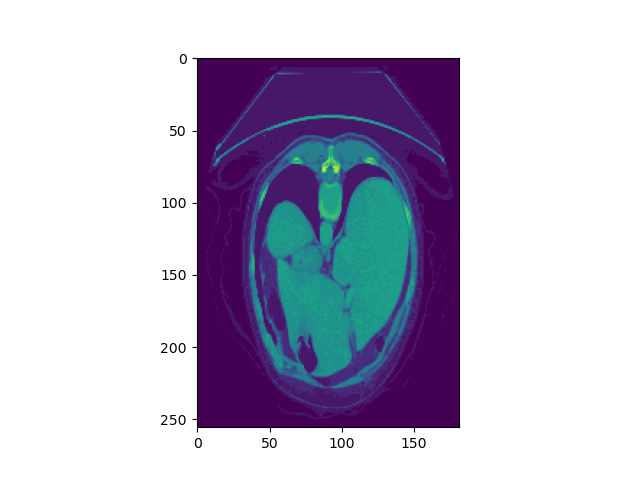

In [44]:
plt.figure()
pli.hyperslicer(phantom.phantom)

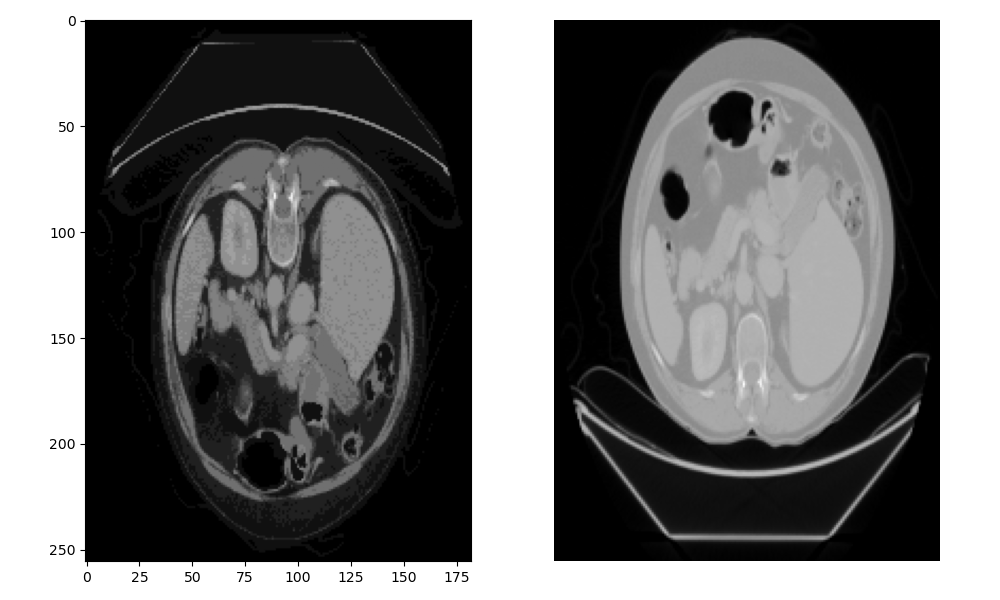

In [49]:
plt.figure(figsize=[10,6])
plt.subplot(121)
plt.imshow(phantom.phantom[31,:,:],cmap='gray',aspect='equal')
# plt.axis('off')
plt.subplot(122)
plt.imshow(np.flipud(phantom.density[31,:,:]),cmap='gray',aspect='equal')
plt.axis('off')
plt.tight_layout()

In [47]:
phantom.phan_map[24]

'SchneiderMaterialsWeight25'

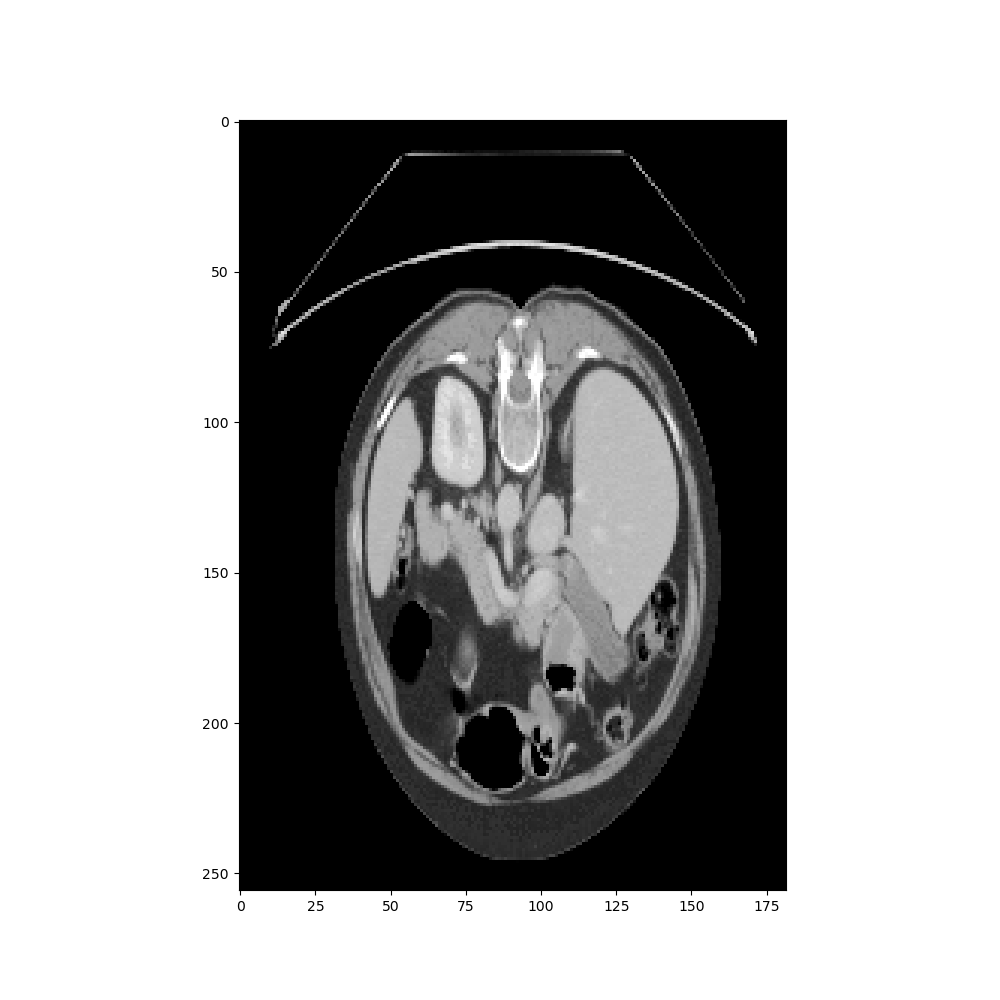

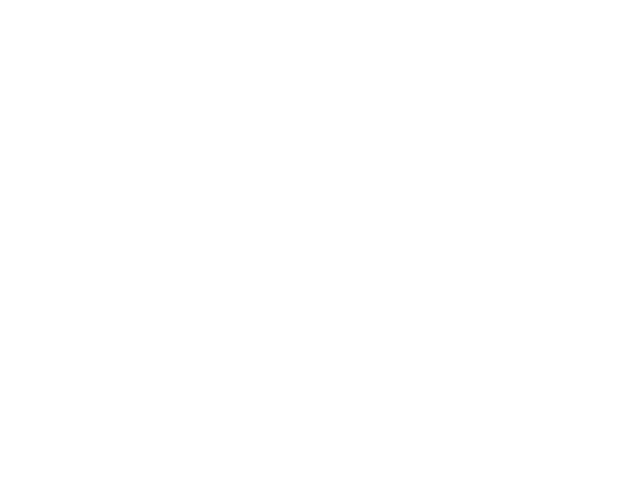

In [52]:
plt.figure()
seg = pli.image_segmenter(phantom.density[31,:,:],cmap='gray',vmin=0.8,vmax=1.2)

display(seg)

In [53]:
mask = seg.mask.astype(bool)

In [54]:
np.save('mask_duo.npy',mask)

In [55]:
mask = np.load('mask_duo.npy')

In [56]:
phantom.phantom[31][mask] = 24
# phantom.phantom[31][mask] += 101

# phantom.phantom[phantom.phantom == 107] = 23
# phantom.phantom[phantom.phantom == 108] = 24

# phantom.phantom[31][mask] -= 100
# # phantom.phantom[31][mask] -= 101

# phantom.phantom[phantom.phantom == 7] = 23
# phantom.phantom[phantom.phantom == 8] = 24


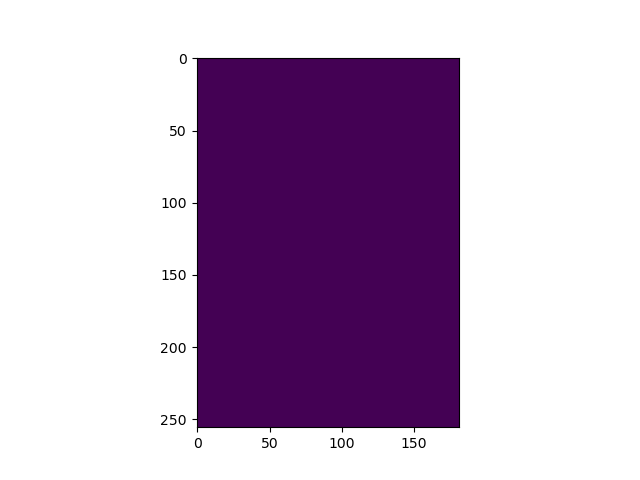

In [58]:
plt.figure()
pli.hyperslicer(phantom.phantom ==24)

In [13]:
# phantom.phantom[phantom.phantom == 23] = 22
# phantom.phantom[phantom.phantom == 24] = 22

In [59]:
print(phantom.geomet)
phantom.geomet.offDetector = np.array([0,0])
phantom.geomet.dDetector = np.array([2.24,2.24])
phantom.geomet.sDetector = phantom.geomet.dDetector*phantom.geomet.nDetector
phantom.is_fullfan = True

TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1510 mm
Distance from source to origin (DSO)= 1000.0 mm
-----
Detector parameters
Number of pixels (nDetector) = [360 360]
Size of each pixel (dDetector) = [1.12 1.12] mm
Total size of the detector (sDetector) = [403.2 403.2] mm
-----
Image parameters
Number of voxels (nVoxel) = [100 256 182]
Total size of the image (sVoxel) = [131.8359   337.499904 455.      ] mm
Size of each voxel (dVoxel) = [1.318359 1.318359 2.5     ] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0 0 0] mm
Offset of detector (offDetector) = [   0.    -159.999] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.5
-----
Rotation of the Detector (rotDetector) = [0 0 0] rad


Low energy image

In [60]:
phantom.energies = np.array([  10,   20,   30,   40,   50,   60,   70,   80, 90, 90.58,  99.5, 100,  102.5, 300,
        500,  700,  900, 1000, 2000, 4000, 6000])

In [61]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

spectrum.x = np.array([ 80,80.5,80.6])
spectrum.y = np.array([0,1,0])

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,480,conv_on=False,energies = phantom.energies)

[2025-01-27 13:04:20,443] {patient_data.py:616} INFO - Making a list of angles
[2025-01-27 13:04:20,444] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer
[2025-01-27 13:04:20,456] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/half_fan_mm.dat
18
18
[2025-01-27 13:04:20,593] {ggems_simulate.py:557} INFO -     Phantom is_patient: True, using mu_over_rho
[2025-01-27 13:04:20,607] {ggems_simulate.py:594} INFO - Running Simulations: 480 Projections
[2025-01-27 13:04:20,608] {ggems_simulate.py:622} INFO -     Simulating 80.0 keV
[2025-01-27 13:04:20,619] {ggems_simulate.py:701} INFO -         Attenuation at 80.0 keV for SchneiderMaterialsWeight2 is 0.18285466256043037
[2025-01-27 13:04:20,627] {ggems_simulate.py:701} INFO -         Attenuation at 80.0 keV for SchneiderMaterialsWeight3 is 0.17988437699208687
[2025-01-27 13:04:20,633] {ggems_simulate.py:701} INFO -         Attenuation at 80.0 keV for Schneider

In [62]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.0,noise_weight=1000000) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

In [63]:
phantom_img_low = phantom.img.copy() + 0.00001

High energy image

In [ ]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

spectrum.x = np.array([99, 99.58, 100])
spectrum.y = np.array([0,1,0])

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,480,conv_on=False)

[2025-01-27 13:04:34,664] {patient_data.py:616} INFO - Making a list of angles
[2025-01-27 13:04:34,664] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer
[2025-01-27 13:04:34,670] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/half_fan_mm.dat
18
18
[2025-01-27 13:04:34,751] {ggems_simulate.py:557} INFO -     Phantom is_patient: True, using mu_over_rho
[2025-01-27 13:04:34,763] {ggems_simulate.py:594} INFO - Running Simulations: 480 Projections
[2025-01-27 13:04:34,764] {ggems_simulate.py:622} INFO -     Simulating 99.5 keV
[2025-01-27 13:04:34,768] {ggems_simulate.py:701} INFO -         Attenuation at 99.5 keV for SchneiderMaterialsWeight2 is 0.17100846103179448
[2025-01-27 13:04:34,772] {ggems_simulate.py:701} INFO -         Attenuation at 99.5 keV for SchneiderMaterialsWeight3 is 0.17009688331272688
[2025-01-27 13:04:34,776] {ggems_simulate.py:701} INFO -         Attenuation at 99.5 keV for Schneider

In [126]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.0,noise_weight=1000000) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

In [127]:
phantom_img_high = phantom.img + 0.00001

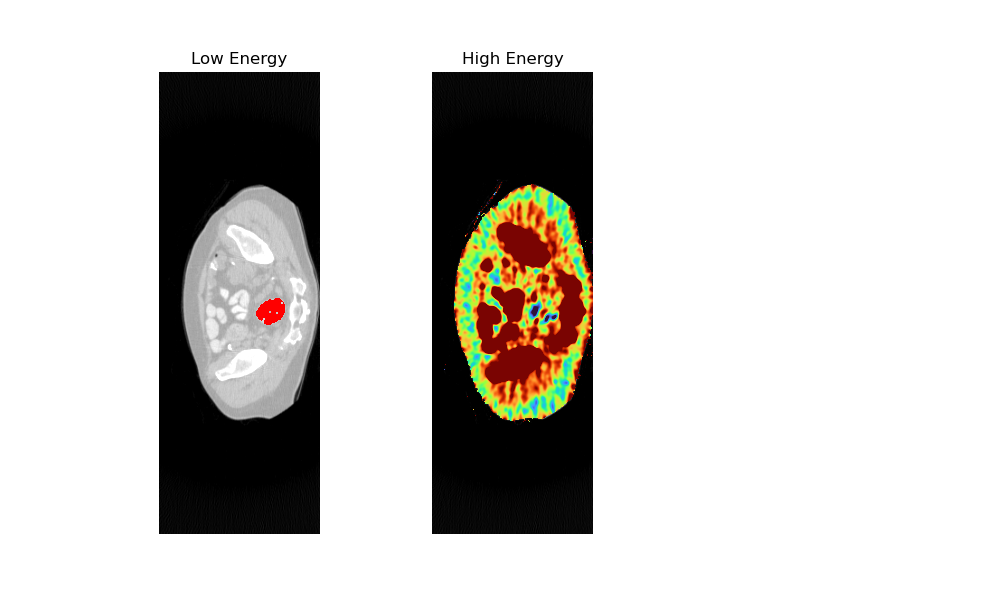

In [128]:
plt.figure(figsize=[10,6])
plt.subplot(131)
plt.imshow(np.flipud(phantom_img_low[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom_img_low[40],40),vmax=np.percentile(phantom_img_low[40],98))
plt.title('Low Energy')
# make a mask of where the phantom.phantom = 10 or 11 in slice 40
mask = (phantom.phantom[31] == 24) | (phantom.phantom[31] == 23)

# binary expand the mask
from scipy.ndimage import binary_dilation
mask = binary_dilation(mask)

# turn the zero entries in the mask to NaN
mask = mask.astype(float)
mask[mask == 0] = np.nan

plt.imshow(np.flipud(mask), cmap='flag')
plt.axis('off')
plt.subplot(132)
plt.imshow(np.flipud(phantom_img_high[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom_img_high[40],40),vmax=np.percentile(phantom_img_high[40],98))
plt.title('High Energy')
plt.axis('off')

# plt.imshow((phantom_img_high[40,:,:]-phantom_img_low[40,:,:]),cmap='bwr_r',aspect='equal')

# gaussian filter the images
from scipy.ndimage import gaussian_filter
img_low = gaussian_filter(phantom_img_low[40,:,:], sigma=2)
img_high = gaussian_filter(phantom_img_high[40,:,:], sigma=2)

# plt.subplot(133)
img_sub = (img_low - img_high)/img_low
# img_sub[ phantom_img_low[40] < 0.02] = 0
# img_sub[-img_sub >-0.0013] = np.NaN
# img_sub[ phantom_img_low[40] > 0.028] = 0
img_sub[phantom.phantom[31] == 0]   = np.NaN
plt.imshow(np.flipud(img_sub),cmap='turbo',aspect='equal',vmin=np.nanpercentile(img_sub,1),vmax=np.nanpercentile(img_sub,70))

# Another few energies

In [129]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

spectrum.x = np.array([ 70,70.5,70.6])
spectrum.y = np.array([0,1,0])

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,480,conv_on=False,energies = phantom.energies)

[2025-01-24 14:57:45,515] {patient_data.py:616} INFO - Making a list of angles
[2025-01-24 14:57:45,516] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer
[2025-01-24 14:57:45,518] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/no_bowtie.dat
18
18
[2025-01-24 14:57:45,736] {ggems_simulate.py:557} INFO -     Phantom is_patient: True, using mu_over_rho
[2025-01-24 14:57:45,756] {ggems_simulate.py:594} INFO - Running Simulations: 480 Projections
[2025-01-24 14:57:45,757] {ggems_simulate.py:622} INFO -     Simulating 70.0 keV
[2025-01-24 14:57:45,766] {ggems_simulate.py:701} INFO -         Attenuation at 70.0 keV for SchneiderMaterialsWeight2 is 0.19287865511795024
[2025-01-24 14:57:45,773] {ggems_simulate.py:701} INFO -         Attenuation at 70.0 keV for SchneiderMaterialsWeight3 is 0.18736478781556362
[2025-01-24 14:57:45,782] {ggems_simulate.py:701} INFO -         Attenuation at 70.0 keV for SchneiderMa

In [130]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.0,noise_weight=1000000) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

In [131]:
phantom_img_low2 = phantom.img.copy() + 0.00001

High energy image

In [132]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

spectrum.x = np.array([102, 102.58, 103])
spectrum.y = np.array([0,1,0])

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,480,conv_on=False)

[2025-01-24 14:57:54,433] {patient_data.py:616} INFO - Making a list of angles
[2025-01-24 14:57:54,434] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer
[2025-01-24 14:57:54,437] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/no_bowtie.dat
18
18
[2025-01-24 14:57:54,648] {ggems_simulate.py:557} INFO -     Phantom is_patient: True, using mu_over_rho
[2025-01-24 14:57:54,667] {ggems_simulate.py:594} INFO - Running Simulations: 480 Projections
[2025-01-24 14:57:54,668] {ggems_simulate.py:622} INFO -     Simulating 102.5 keV
[2025-01-24 14:57:54,676] {ggems_simulate.py:701} INFO -         Attenuation at 102.5 keV for SchneiderMaterialsWeight2 is 0.15007504468440008
[2025-01-24 14:57:54,683] {ggems_simulate.py:701} INFO -         Attenuation at 102.5 keV for SchneiderMaterialsWeight3 is 0.15061455231036902
[2025-01-24 14:57:54,691] {ggems_simulate.py:701} INFO -         Attenuation at 102.5 keV for Schneid

In [133]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.0,noise_weight=1000000) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

In [134]:
phantom_img_high2 = phantom.img + 0.00001

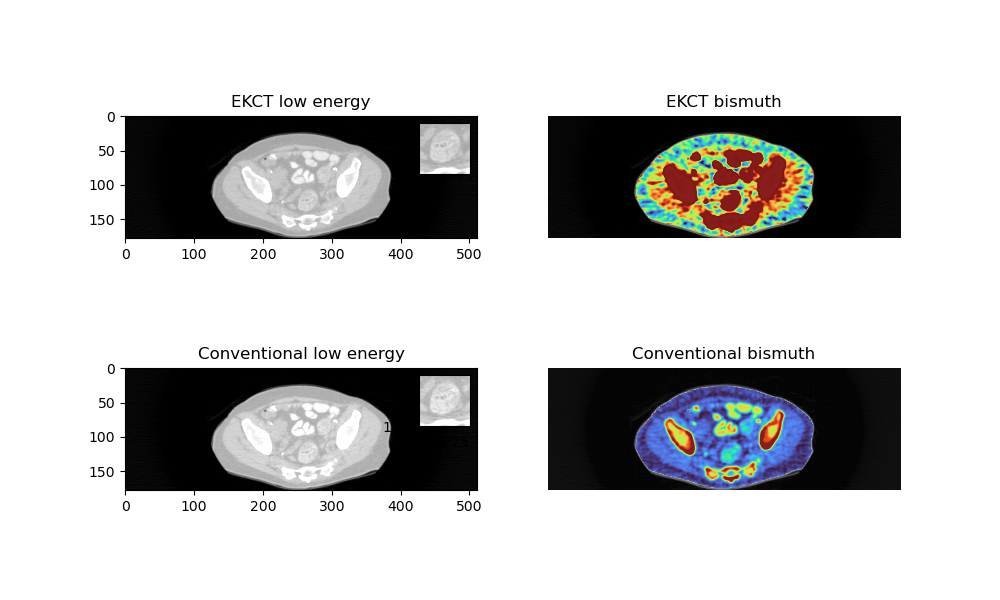

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_fill_holes, gaussian_filter
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

plt.figure(figsize=[10,6])

# First subplot
plt.subplot(221)
plt.imshow(np.rot90(phantom_img_low[40,:,:], 3), cmap='gray', aspect='equal', vmin=np.percentile(phantom_img_low[40], 40), vmax=np.percentile(phantom_img_low[40], 98))
plt.title('EKCT low energy')
# plt.axis('off')

# Create a mask where the phantom.phantom equals 10 or 11 in slice 40
mask = (phantom.phantom[31] == 23) | (phantom.phantom[31] == 24)

# Binary expand the mask
mask = binary_dilation(mask)
mask = binary_fill_holes(mask)


mask_2 = np.rot90(mask, 3)


# Turn the zero entries in the mask to NaN
mask = mask.astype(float)
mask[mask == 0] = np.nan

# plt.imshow(np.rot90(mask, 3), cmap='flag', alpha=0.5)

# Zoom inset
axins1 = zoomed_inset_axes(plt.gca(), 1.5, loc='upper right')
axins1.imshow(np.rot90(phantom_img_low[40,:,:], 3), cmap='gray', aspect='equal', vmin=np.percentile(phantom_img_low[40], 40), vmax=np.percentile(phantom_img_low[40], 98))
axins1.imshow(np.rot90(mask, 3), cmap='flag', alpha=0.5)

# make a bounding box around the mask


x1, x2, y1, y2 = 240,  290, 150, 100  # Specify the zoom area
axins1.set_xlim(x1, x2)
axins1.set_ylim(y1, y2)
# axins1.axis('off')
axins1.yaxis.get_major_locator().set_params(nbins=7)
axins1.xaxis.get_major_locator().set_params(nbins=7)
axins1.tick_params(labelleft=False, labelbottom=False)
# mark_inset(plt.gca(), axins1, loc1=1.5, loc2=4, fc="none", ec="0.5")

# Second subplot
plt.subplot(222)
plt.imshow(np.rot90(phantom_img_high[40,:,:], 3), cmap='gray', aspect='equal', vmin=np.percentile(phantom_img_high[40], 40), vmax=np.percentile(phantom_img_high[40], 98))
plt.title('EKCT bismuth')
plt.axis('off')

img_low = gaussian_filter(phantom_img_low[40,:,:], sigma=2)
img_high = gaussian_filter(phantom_img_high[40,:,:], sigma=2)
img_sub = (img_low - img_high) / img_low
img_sub[phantom.density[31] < 0.5] = np.NaN
plt.imshow(np.rot90(img_sub, 3), cmap='turbo', aspect='equal', vmin=np.nanpercentile(img_sub, 0.5), vmax=np.nanpercentile(img_sub, 70), alpha=0.9)

# Third subplot
plt.subplot(223)
plt.imshow(np.rot90(phantom_img_low2[40,:,:], 3), cmap='gray', aspect='equal', vmin=np.percentile(phantom_img_low2[40], 40), vmax=np.percentile(phantom_img_low[40], 98))
plt.title('Conventional low energy')
# plt.axis('off')

# Create a mask where the phantom.phantom equals 10 or 11 in slice 40
mask2 = (phantom.phantom[31] == 23) | (phantom.phantom[31] == 24)

# Binary expand the mask
mask2 = binary_dilation(mask2)
mask2 = binary_fill_holes(mask2)

# Turn the zero entries in the mask to NaN
mask2 = mask2.astype(float)
mask2[mask2 == 0] = np.nan

plt.imshow(np.rot90(mask2, 3), cmap='flag', alpha=0.5)

# Zoom inset
axins2 = zoomed_inset_axes(plt.gca(), 1.5, loc='upper right')
axins2.imshow(np.rot90(phantom_img_low2[40,:,:], 3), cmap='gray', aspect='equal', vmin=np.percentile(phantom_img_low2[40], 40), vmax=np.percentile(phantom_img_low[40], 98))
axins2.imshow(np.rot90(mask2, 3), cmap='flag', alpha=0.5)
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)
# axins2.axis('off')
# mark_inset(plt.gca(), axins1.5, loc1=1.5, loc2=4, fc="none", ec="0.5")

# Fourth subplot
plt.subplot(224)
plt.imshow(np.rot90(phantom_img_high2[40,:,:], 3), cmap='gray', aspect='equal', vmin=np.percentile(phantom_img_high2[40], 0.5), vmax=np.percentile(phantom_img_high[40], 98))
plt.title('Conventional bismuth')
plt.axis('off')

# Gaussian filter the images
img_low2 = gaussian_filter(phantom_img_low2[40,:,:], sigma=1.5)
img_high2 = gaussian_filter(phantom_img_high2[40,:,:], sigma=1.5)
img_sub2 = (img_low2 - img_high2) / img_low2
img_sub2[phantom.density[31] < 0.5] = np.NaN

plt.imshow(np.rot90(img_sub2, 3), cmap='turbo', aspect='equal', vmin=np.nanpercentile(img_sub2, 0.5), vmax=np.nanpercentile(img_sub2, 98), alpha=0.9)

# plt.tight_layout()
# plt.show()

/tmp/ipykernel_45966/2182906026.py:2: RuntimeWarning: invalid value encountered in log
  log_subtracted = np.log(gaussian_filter(phantom_img_high[40,:,:]/phantom_img_low[40,:,:],1.5))
/tmp/ipykernel_45966/2182906026.py:7: RuntimeWarning: invalid value encountered in log
  log_subtracted2 = np.log(gaussian_filter(phantom_img_high2[40,:,:]/phantom_img_low2[40,:,:],1.5))


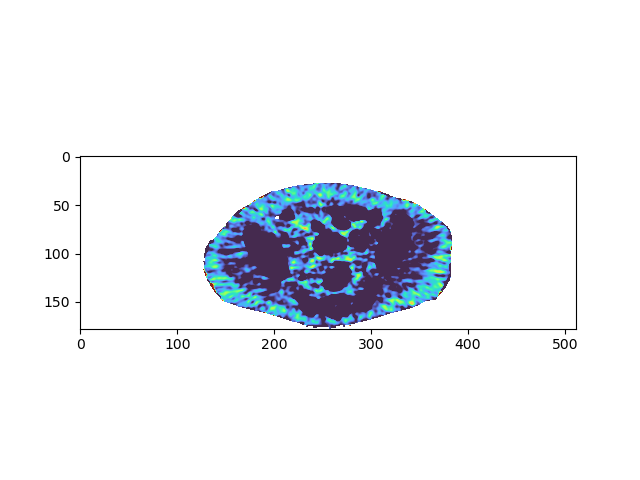

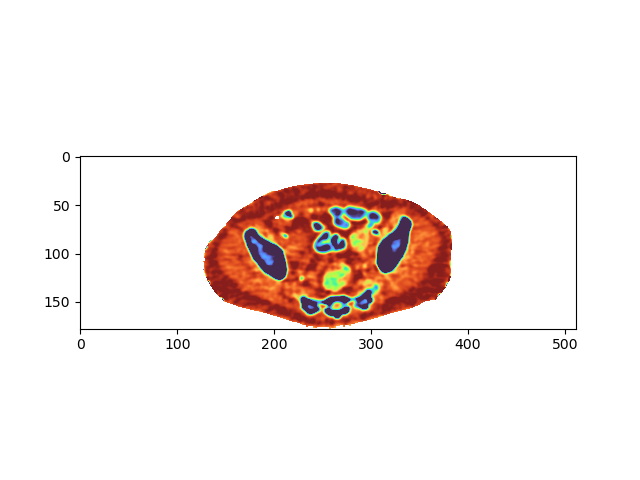

In [30]:
plt.figure()
log_subtracted = np.log(gaussian_filter(phantom_img_high[40,:,:]/phantom_img_low[40,:,:],1.5))
log_subtracted[phantom.density[31] < 0.5] = np.NaN
plt.imshow(np.rot90(log_subtracted, 3), cmap='turbo', aspect='equal', vmin=np.nanpercentile(log_subtracted, 45), vmax=np.nanpercentile(log_subtracted, 99.5), alpha=0.9)

plt.figure()
log_subtracted2 = np.log(gaussian_filter(phantom_img_high2[40,:,:]/phantom_img_low2[40,:,:],1.5))
log_subtracted2[phantom.density[31] < 0.5] = np.NaN
plt.imshow(np.rot90(log_subtracted2, 3), cmap='turbo', aspect='equal', vmin=np.nanpercentile(log_subtracted2, 10), vmax=np.nanpercentile(log_subtracted2, 90), alpha=0.9)

/tmp/ipykernel_45966/4239075839.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


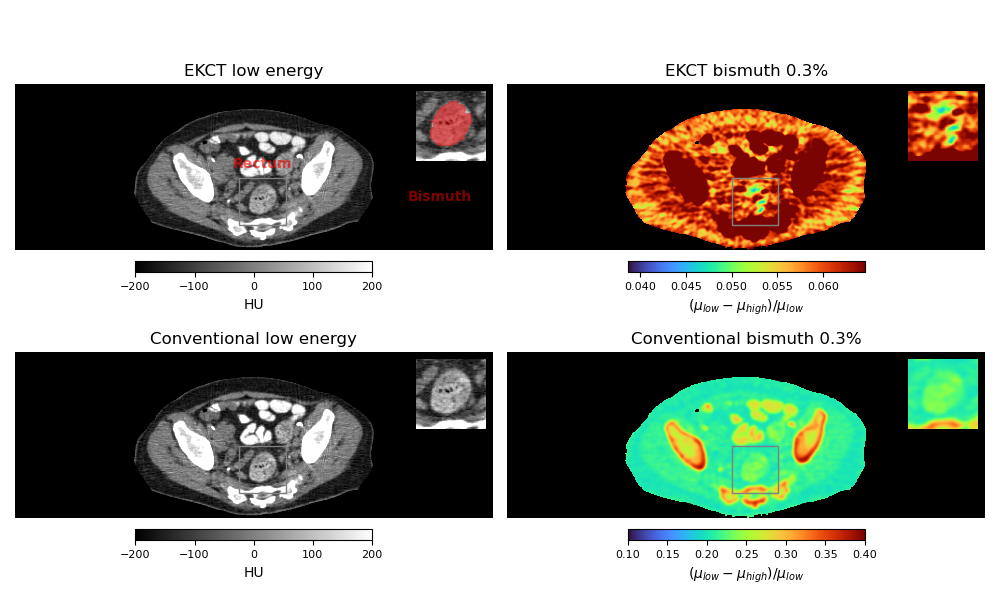

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_fill_holes, gaussian_filter
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, inset_axes

# Example water attenuation values for each image
mu_water_low = phantom_img_low[40,170:200,120:130].mean()
mu_water_high = phantom_img_high[40,170:200,120:130].mean()
mu_water_low2 = phantom_img_low2[40,170:200,120:130].mean()
mu_water_high2 = phantom_img_high2[40,170:200,120:130].mean()

# Convert attenuation to HU
phantom_img_low_HU = 1000 * (phantom_img_low - mu_water_low) / mu_water_low
phantom_img_high_HU = 1000 * (phantom_img_high - mu_water_high) / mu_water_high
phantom_img_low2_HU = 1000 * (phantom_img_low2 - mu_water_low2) / mu_water_low2
phantom_img_high2_HU = 1000 * (phantom_img_high2 - mu_water_high2) / mu_water_high2

plt.figure(figsize=[10,6])

vmax_sum = np.nanpercentile(img_sub, 70)
vmin_sub = -np.nanpercentile(img_sub, 0.5)
# First subplot
ax1 = plt.subplot(221)
im1 = ax1.imshow(np.rot90(phantom_img_low_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax1.set_title('EKCT low energy')
ax1.axis('off')

# Create a mask where the phantom.phantom equals 10 or 11 in slice 40
mask = (phantom.phantom[31] == 23) | (phantom.phantom[31] == 24)

# Binary expand the mask
mask = binary_dilation(mask)
mask = binary_fill_holes(mask)

# Turn the zero entries in the mask to NaN
mask = mask.astype(float)
mask[mask == 0] = np.nan

ax1.text(265, 85, 'Rectum', color='red', fontsize=10, weight='bold', ha='center', va='center', alpha=0.6)
ax1.text(455, 120, 'Bismuth', color='red', fontsize=10, weight='bold', ha='center', va='center', alpha=0.5)

# Zoom inset
axins1 = zoomed_inset_axes(ax1, 1.5, loc='upper right')

axins1.imshow(np.rot90(phantom_img_low_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
axins1.imshow(np.rot90(mask, 3), cmap='flag', alpha=0.5)
x1, x2, y1, y2 = 240, 290, 150, 100  # Specify the zoom area
axins1.set_xlim(x1, x2)
axins1.set_ylim(y1, y2)
axins1.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax1.add_patch(rect)

# Add horizontal colorbar
cbar1 = plt.colorbar(im1, ax=ax1, orientation='horizontal', fraction=0.046, pad=0.04,label='HU')
cbar1.ax.tick_params(labelsize=8)

# Second subplot
ax2 = plt.subplot(222)
im2 = ax2.imshow(np.rot90(phantom_img_high_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax2.set_title('EKCT bismuth 0.15%')
ax2.axis('off')

img_low = gaussian_filter(phantom_img_low[40,:,:], sigma=1.5)
img_high = gaussian_filter(phantom_img_high[40,:,:], sigma=1.5)
img_sub = (img_low - img_high) / img_low
img_sub[phantom.density[31] < 0.5] = np.NaN
im2 = ax2.imshow(np.rot90(img_sub, 3), cmap='turbo', aspect='equal', vmin=-vmin_sub, vmax=vmax_sum)

axins3 = zoomed_inset_axes(ax2, 1.5, loc='upper right')
axins3.imshow(np.rot90(img_sub, 3), cmap='turbo', aspect='equal', vmin=-vmin_sub, vmax=vmax_sum)
axins3.set_ylim(y1, y2)
axins3.set_xlim(x1, x2)
axins3.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax2.add_patch(rect)

# Add horizontal colorbar
cbar2 = plt.colorbar(im2, ax=ax2, orientation='horizontal', fraction=0.046, pad=0.04,label='$(\mu_{low}-\mu_{high})/\mu_{low}$')
cbar2.ax.tick_params(labelsize=8)

# Third subplot
ax3 = plt.subplot(223)
im3 = ax3.imshow(np.rot90(phantom_img_low2_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax3.set_title('Conventional low energy')
ax3.axis('off')

# Create a mask where the phantom.phantom equals 10 or 11 in slice 40
mask2 = (phantom.phantom[31] == 23) | (phantom.phantom[31] == 24)

# Binary expand the mask
mask2 = binary_dilation(mask2)
mask2 = binary_fill_holes(mask2)

# Turn the zero entries in the mask to NaN
mask2 = mask2.astype(float)
mask2[mask2 == 0] = np.nan



# Zoom inset
axins2 = zoomed_inset_axes(ax3, 1.5, loc='upper right')
axins2.imshow(np.rot90(phantom_img_low2_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
# axins2.imshow(np.rot90(mask2, 3), cmap='flag', alpha=0.5)
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)
axins2.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax3.add_patch(rect)

# Add horizontal colorbar
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', fraction=0.046, pad=0.04,label='HU')
cbar3.ax.tick_params(labelsize=8)

# Fourth subplot
ax4 = plt.subplot(224)
im4 = ax4.imshow(np.rot90(phantom_img_high2_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax4.set_title('Conventional bismuth 0.15%')
ax4.axis('off')

# Gaussian filter the images
img_low2 = gaussian_filter(phantom_img_low2[40,:,:], sigma=1.5)
img_high2 = gaussian_filter(phantom_img_high2[40,:,:], sigma=1.5)
img_sub2 = (img_low2 - img_high2) / img_low2

vmax_sum2 = np.nanpercentile(img_sub2, 70)
vmin_sub2 = -np.nanpercentile(img_sub2, 0.5)

img_sub2[phantom.density[31] < 0.5] = np.NaN

im4 = ax4.imshow(np.rot90(img_sub2, 3), cmap='turbo', aspect='equal', vmin=0.1, vmax=0.4)
axins4 = zoomed_inset_axes(ax4, 1.5, loc='upper right')
axins4.imshow(np.rot90(img_sub2, 3), cmap='turbo', aspect='equal', vmin=0.1, vmax=0.4)
axins4.set_xlim(x1, x2)
axins4.set_ylim(y1, y2)
axins4.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax4.add_patch(rect)

# Add horizontal colorbar
cbar4 = plt.colorbar(im4, ax=ax4, orientation='horizontal', fraction=0.046, pad=0.04,label='$(\mu_{low}-\mu_{high})/\mu_{low}$')
cbar4.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

plt.savefig('ekct_03.png', dpi=300)

/tmp/ipykernel_45966/3037502911.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


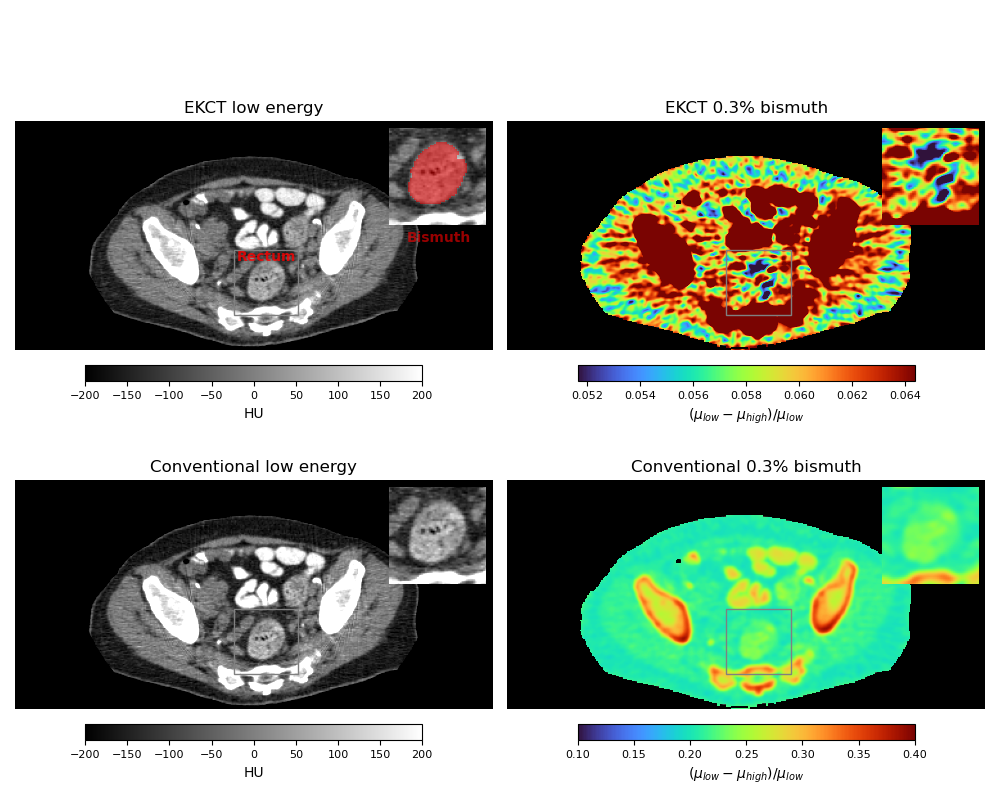

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_fill_holes, gaussian_filter
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes

# Example water attenuation values for each image
mu_water_low = phantom_img_low[40,170:200,120:130].mean()
mu_water_high = phantom_img_high[40,170:200,120:130].mean()
mu_water_low2 = phantom_img_low2[40,170:200,120:130].mean()
mu_water_high2 = phantom_img_high2[40,170:200,120:130].mean()

# Convert attenuation to HU
phantom_img_low_HU = 1000 * (phantom_img_low - mu_water_low) / mu_water_low
phantom_img_high_HU = 1000 * (phantom_img_high - mu_water_high) / mu_water_high
phantom_img_low2_HU = 1000 * (phantom_img_low2 - mu_water_low2) / mu_water_low2
phantom_img_high2_HU = 1000 * (phantom_img_high2 - mu_water_high2) / mu_water_high2

# Crop the y-axis by 100 entries on each side
crop_y = 70
phantom_img_low_HU = phantom_img_low_HU[:, crop_y:-crop_y, :]
phantom_img_high_HU = phantom_img_high_HU[:, crop_y:-crop_y, :]
phantom_img_low2_HU = phantom_img_low2_HU[:, crop_y:-crop_y, :]
phantom_img_high2_HU = phantom_img_high2_HU[:, crop_y:-crop_y, :]

plt.figure(figsize=[10,8])

vmax_sum = np.nanpercentile(img_sub, 70)
vmin_sub = -np.nanpercentile(img_sub, 0.5)

# First subplot
ax1 = plt.subplot(221)
im1 = ax1.imshow(np.rot90(phantom_img_low_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax1.set_title('EKCT low energy')
ax1.axis('off')

# Create a mask where the phantom.phantom equals 10 or 11 in slice 40
mask = (phantom.phantom[31] == 23) | (phantom.phantom[31] == 24)

# Binary expand the mask
mask = binary_dilation(mask)
mask = binary_fill_holes(mask)

# Turn the zero entries in the mask to NaN
mask = mask.astype(float)
mask[mask == 0] = np.NaN

ax1.text(265 - crop_y, 105, 'Rectum', color='red', fontsize=10, weight='bold', ha='center', va='center', alpha=0.8)
ax1.text(455 - 2*crop_y + 15, 90, 'Bismuth', color='red', fontsize=10, weight='bold', ha='center', va='center', alpha=0.6)

# Zoom inset
axins1 = zoomed_inset_axes(ax1, 1.5, loc='upper right')

axins1.imshow(np.rot90(phantom_img_low_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
axins1.imshow(np.rot90(mask[crop_y:-crop_y, :], 3), cmap='flag', alpha=0.5)
x1, x2, y1, y2 = 240 - crop_y, 290 - crop_y, 150, 100  # Specify the zoom area
axins1.set_xlim(x1, x2)
axins1.set_ylim(y1, y2)
axins1.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax1.add_patch(rect)

# Add horizontal colorbar
cbar1 = plt.colorbar(im1, ax=ax1, orientation='horizontal', fraction=0.046, pad=0.04, label='HU')
cbar1.ax.tick_params(labelsize=8)

# Second subplot
ax2 = plt.subplot(222)
im2 = ax2.imshow(np.rot90(phantom_img_high_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax2.set_title('EKCT 0.15% bismuth')
ax2.axis('off')

img_low = gaussian_filter(phantom_img_low[40,crop_y:-crop_y,:], sigma=1.5)
img_high = gaussian_filter(phantom_img_high[40,crop_y:-crop_y,:], sigma=1.5)
img_sub = (img_low - img_high) / img_low
img_sub[phantom.density[31,crop_y:-crop_y,:] < 0.5] = np.NaN
im2 = ax2.imshow(np.rot90(img_sub, 3), cmap='turbo', aspect='equal', vmin=-vmin_sub, vmax=vmax_sum)

axins3 = zoomed_inset_axes(ax2, 1.5, loc='upper right')
axins3.imshow(np.rot90(img_sub, 3), cmap='turbo', aspect='equal', vmin=-vmin_sub, vmax=vmax_sum)
axins3.set_ylim(y1, y2)
axins3.set_xlim(x1, x2)
axins3.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax2.add_patch(rect)

# Add horizontal colorbar
cbar2 = plt.colorbar(im2, ax=ax2, orientation='horizontal', fraction=0.046, pad=0.04, label='$(\mu_{low}-\mu_{high})/\mu_{low}$')
cbar2.ax.tick_params(labelsize=8)

# Third subplot
ax3 = plt.subplot(223)
im3 = ax3.imshow(np.rot90(phantom_img_low2_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax3.set_title('Conventional low energy')
ax3.axis('off')

# Create a mask where the phantom.phantom equals 10 or 11 in slice 40
mask2 = (phantom.phantom[31] == 23) | (phantom.phantom[31] == 24)

# Binary expand the mask
mask2 = binary_dilation(mask2)
mask2 = binary_fill_holes(mask2)

# Turn the zero entries in the mask to NaN
mask2 = mask2.astype(float)
mask2[mask2 == 0] = np.nan

# Zoom inset
axins2 = zoomed_inset_axes(ax3, 1.5, loc='upper right')
axins2.imshow(np.rot90(phantom_img_low2_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)
axins2.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax3.add_patch(rect)

# Add horizontal colorbar
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', fraction=0.046, pad=0.04, label='HU')
cbar3.ax.tick_params(labelsize=8)

# Fourth subplot
ax4 = plt.subplot(224)
im4 = ax4.imshow(np.rot90(phantom_img_high2_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax4.set_title('Conventional 0.15% bismuth')
ax4.axis('off')

# Gaussian filter the images
img_low2 = gaussian_filter(phantom_img_low2[40,crop_y:-crop_y,:], sigma=1.5)
img_high2 = gaussian_filter(phantom_img_high2[40,crop_y:-crop_y,:], sigma=1.5)
img_sub2 = (img_low2 - img_high2) / img_low2

vmax_sum2 = np.nanpercentile(img_sub2, 70)
vmin_sub2 = -np.nanpercentile(img_sub2, 0.5)

img_sub2[phantom.density[31,crop_y:-crop_y,:] < 0.5] = np.NaN

im4 = ax4.imshow(np.rot90(img_sub2, 3), cmap='turbo', aspect='equal', vmin=0.1, vmax=0.4)
axins4 = zoomed_inset_axes(ax4, 1.5, loc='upper right')
axins4.imshow(np.rot90(img_sub2, 3), cmap='turbo', aspect='equal', vmin=0.1, vmax=0.4)
axins4.set_xlim(x1, x2)
axins4.set_ylim(y1, y2)
axins4.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax4.add_patch(rect)

# Add horizontal colorbar
cbar4 = plt.colorbar(im4, ax=ax4, orientation='horizontal', fraction=0.046, pad=0.04, label='$(\mu_{low}-\mu_{high})/\mu_{low}$')
cbar4.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# plt.savefig('ekct.png', dpi=300)

In [155]:
img_sub = np.load('img_sub.npy')
img_sub2 = np.load('img_sub2.npy')

In [156]:
img_sub[np.isnan(img_sub)] = 0
img_sub2[np.isnan(img_sub2)] = 0

In [157]:
from scipy.ndimage import zoom

img_sub = zoom(img_sub, 2,order=1)
img_sub2 = zoom(img_sub2, 2,order=1)

In [158]:
img_sub[phantom.density[31] < 0.5] = np.NaN
img_sub2[phantom.density[31] < 0.5] = np.NaN

img_sub = img_sub[crop_y:-crop_y, :]
img_sub2 = img_sub2[crop_y:-crop_y, :]

/tmp/ipykernel_45966/1611945794.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


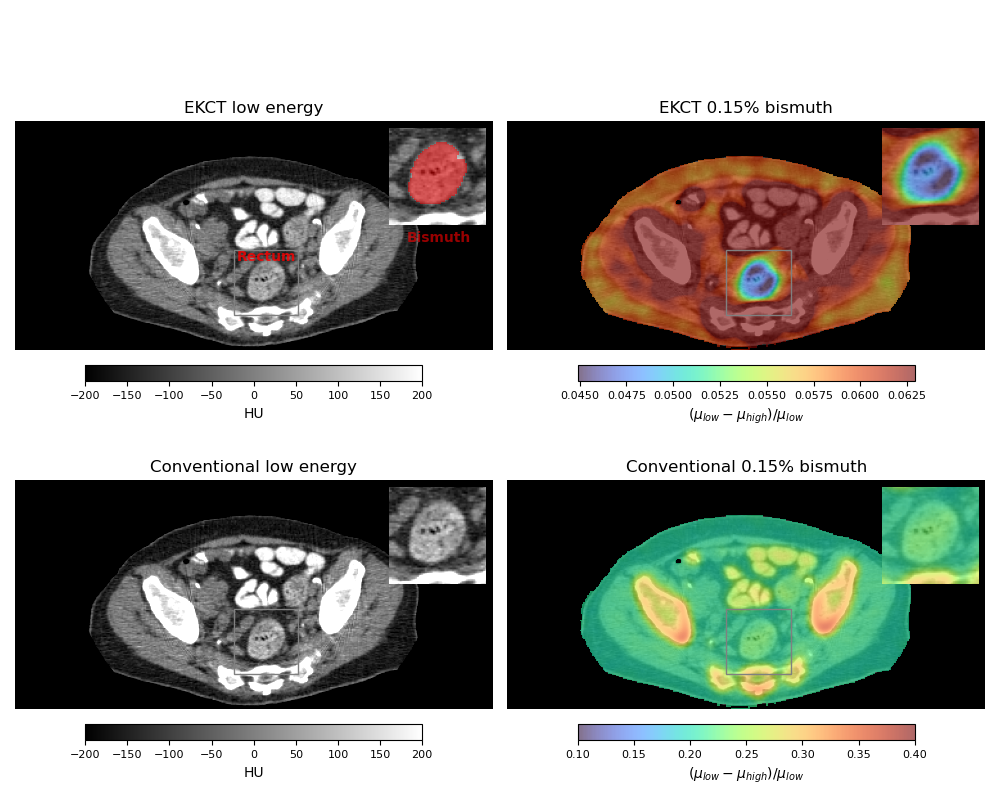

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_fill_holes, gaussian_filter
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes

# Example water attenuation values for each image
mu_water_low = phantom_img_low[40,170:200,120:130].mean()
mu_water_high = phantom_img_high[40,170:200,120:130].mean()
mu_water_low2 = phantom_img_low2[40,170:200,120:130].mean()
mu_water_high2 = phantom_img_high2[40,170:200,120:130].mean()

# Convert attenuation to HU
phantom_img_low_HU = 1000 * (phantom_img_low - mu_water_low) / mu_water_low
phantom_img_high_HU = 1000 * (phantom_img_high - mu_water_high) / mu_water_high
phantom_img_low2_HU = 1000 * (phantom_img_low2 - mu_water_low2) / mu_water_low2
phantom_img_high2_HU = 1000 * (phantom_img_high2 - mu_water_high2) / mu_water_high2

# Crop the y-axis by 100 entries on each side
crop_y = 70
phantom_img_low_HU = phantom_img_low_HU[:, crop_y:-crop_y, :]
phantom_img_high_HU = phantom_img_high_HU[:, crop_y:-crop_y, :]
phantom_img_low2_HU = phantom_img_low2_HU[:, crop_y:-crop_y, :]
phantom_img_high2_HU = phantom_img_high2_HU[:, crop_y:-crop_y, :]

plt.figure(figsize=[10,8])

vmax_sum = np.nanpercentile(img_sub, 60)
vmin_sub = -np.nanpercentile(img_sub, 0.1)

# First subplot
ax1 = plt.subplot(221)
im1 = ax1.imshow(np.rot90(phantom_img_low_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax1.set_title('EKCT low energy')
ax1.axis('off')

# Create a mask where the phantom.phantom equals 10 or 11 in slice 40
mask = (phantom.phantom[31] == 23) | (phantom.phantom[31] == 24)

# Binary expand the mask
mask = binary_dilation(mask)
mask = binary_fill_holes(mask)

# Turn the zero entries in the mask to NaN
mask = mask.astype(float)
mask[mask == 0] = np.NaN

ax1.text(265 - crop_y, 105, 'Rectum', color='red', fontsize=10, weight='bold', ha='center', va='center', alpha=0.8)
ax1.text(455 - 2*crop_y + 15, 90, 'Bismuth', color='red', fontsize=10, weight='bold', ha='center', va='center', alpha=0.6)

# Zoom inset
axins1 = zoomed_inset_axes(ax1, 1.5, loc='upper right')

axins1.imshow(np.rot90(phantom_img_low_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
axins1.imshow(np.rot90(mask[crop_y:-crop_y, :], 3), cmap='flag', alpha=0.5)
x1, x2, y1, y2 = 240 - crop_y, 290 - crop_y, 150, 100  # Specify the zoom area
axins1.set_xlim(x1, x2)
axins1.set_ylim(y1, y2)
axins1.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax1.add_patch(rect)

# Add horizontal colorbar
cbar1 = plt.colorbar(im1, ax=ax1, orientation='horizontal', fraction=0.046, pad=0.04, label='HU')
cbar1.ax.tick_params(labelsize=8)

# Second subplot
ax2 = plt.subplot(222)
im2 = ax2.imshow(np.rot90(phantom_img_high_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax2.set_title('EKCT 0.15% bismuth')
ax2.axis('off')

# img_low = gaussian_filter(phantom_img_low[40,crop_y:-crop_y,:], sigma=1.5)
# img_high = gaussian_filter(phantom_img_high[40,crop_y:-crop_y,:], sigma=1.5)
# img_sub = (img_low - img_high) / img_low
# img_sub[phantom.density[31,crop_y:-crop_y,:] < 0.5] = np.NaN

# img_sub[img_sub > 0.06] = np.NaN
im2 = ax2.imshow(np.rot90(img_sub, 3), cmap='turbo', aspect='equal', vmin=-vmin_sub, vmax=vmax_sum,alpha=0.6)

axins3 = zoomed_inset_axes(ax2, 1.5, loc='upper right')
axins3.imshow(np.rot90(phantom_img_high_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
axins3.imshow(np.rot90(img_sub, 3), cmap='turbo', aspect='equal', vmin=-vmin_sub, vmax=vmax_sum,alpha=0.6)
axins3.set_ylim(y1, y2)
axins3.set_xlim(x1, x2)
axins3.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax2.add_patch(rect)

# Add horizontal colorbar
cbar2 = plt.colorbar(im2, ax=ax2, orientation='horizontal', fraction=0.046, pad=0.04, label='$(\mu_{low}-\mu_{high})/\mu_{low}$')
cbar2.ax.tick_params(labelsize=8)

# Third subplot
ax3 = plt.subplot(223)
im3 = ax3.imshow(np.rot90(phantom_img_low2_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax3.set_title('Conventional low energy')
ax3.axis('off')

# Create a mask where the phantom.phantom equals 10 or 11 in slice 40
mask2 = (phantom.phantom[31] == 23) | (phantom.phantom[31] == 24)

# Binary expand the mask
mask2 = binary_dilation(mask2)
mask2 = binary_fill_holes(mask2)

# Turn the zero entries in the mask to NaN
mask2 = mask2.astype(float)
mask2[mask2 == 0] = np.nan

# Zoom inset
axins2 = zoomed_inset_axes(ax3, 1.5, loc='upper right')
axins2.imshow(np.rot90(phantom_img_low2_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)
axins2.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax3.add_patch(rect)

# Add horizontal colorbar
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', fraction=0.046, pad=0.04, label='HU')
cbar3.ax.tick_params(labelsize=8)

# Fourth subplot
ax4 = plt.subplot(224)
im4 = ax4.imshow(np.rot90(phantom_img_high2_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
ax4.set_title('Conventional 0.15% bismuth')
ax4.axis('off')

# Gaussian filter the images
# img_low2 = gaussian_filter(phantom_img_low2[40,crop_y:-crop_y,:], sigma=1.5)
# img_high2 = gaussian_filter(phantom_img_high2[40,crop_y:-crop_y,:], sigma=1.5)
# img_sub2 = (img_low2 - img_high2) / img_low2

vmax_sum2 = np.nanpercentile(img_sub2, 70)
vmin_sub2 = -np.nanpercentile(img_sub2, 0.5)

img_sub2[phantom.density[31,crop_y:-crop_y,:] < 0.5] = np.NaN

# img_sub2[img_sub2 > 0.35] = np.NaN
im4 = ax4.imshow(np.rot90(img_sub2, 3), cmap='turbo', aspect='equal', vmin=0.1, vmax=0.4,alpha=0.6)
axins4 = zoomed_inset_axes(ax4, 1.5, loc='upper right')
axins4.imshow(np.rot90(phantom_img_high2_HU[40,:,:], 3), cmap='gray', aspect='equal', vmin=-200, vmax=200)
axins4.imshow(np.rot90(img_sub2, 3), cmap='turbo', aspect='equal', vmin=0.1, vmax=0.4,alpha=0.6)
axins4.set_xlim(x1, x2)
axins4.set_ylim(y1, y2)
axins4.axis('off')

# Draw the rectangle for the inset box
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', facecolor='none', lw=1)
ax4.add_patch(rect)

# Add horizontal colorbar
cbar4 = plt.colorbar(im4, ax=ax4, orientation='horizontal', fraction=0.046, pad=0.04, label='$(\mu_{low}-\mu_{high})/\mu_{low}$')
cbar4.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

plt.savefig('ekct.png', dpi=300)

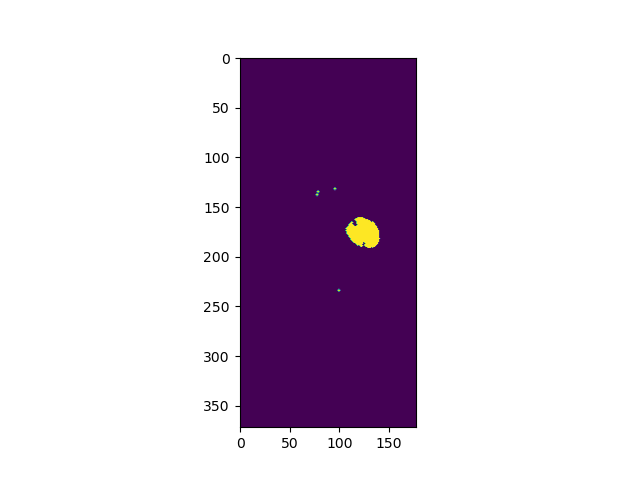

In [ ]:
plt.figure()

# Create a mask where the phantom.phantom equals 10 or 11 in slice 40
mask = (phantom.phantom[31] == 22) | (phantom.phantom[31] == 23)

# Binary expand the mask
mask = binary_dilation(mask)
mask = binary_fill_holes(mask)

# Turn the zero entries in the mask to NaN
# mask = mask.astype(float)
# mask[mask == 0] = np.NaN

plt.imshow(mask[crop_y:-crop_y, :])

In [374]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

spectrum.x = np.array([99, 99.1, 99.2])
spectrum.y = np.array([0,1,0])

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,480,conv_on=False)

[2025-01-23 17:47:19,227] {patient_data.py:616} INFO - Making a list of angles
[2025-01-23 17:47:19,228] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer
[2025-01-23 17:47:19,230] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/no_bowtie.dat
18
18
[2025-01-23 17:47:19,453] {ggems_simulate.py:557} INFO -     Phantom is_patient: True, using mu_over_rho
[2025-01-23 17:47:19,474] {ggems_simulate.py:594} INFO - Running Simulations: 480 Projections
[2025-01-23 17:47:19,475] {ggems_simulate.py:622} INFO -     Simulating 99.5 keV
[2025-01-23 17:47:19,482] {ggems_simulate.py:701} INFO -         Attenuation at 99.5 keV for SchneiderMaterialsWeight2 is 0.17100846103179448
[2025-01-23 17:47:19,491] {ggems_simulate.py:701} INFO -         Attenuation at 99.5 keV for SchneiderMaterialsWeight3 is 0.17009688331272688
[2025-01-23 17:47:19,498] {ggems_simulate.py:701} INFO -         Attenuation at 99.5 keV for SchneiderMa

In [375]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.0,noise_weight=1000000) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

In [376]:
phantom_img_99 = phantom.img + 0.00001

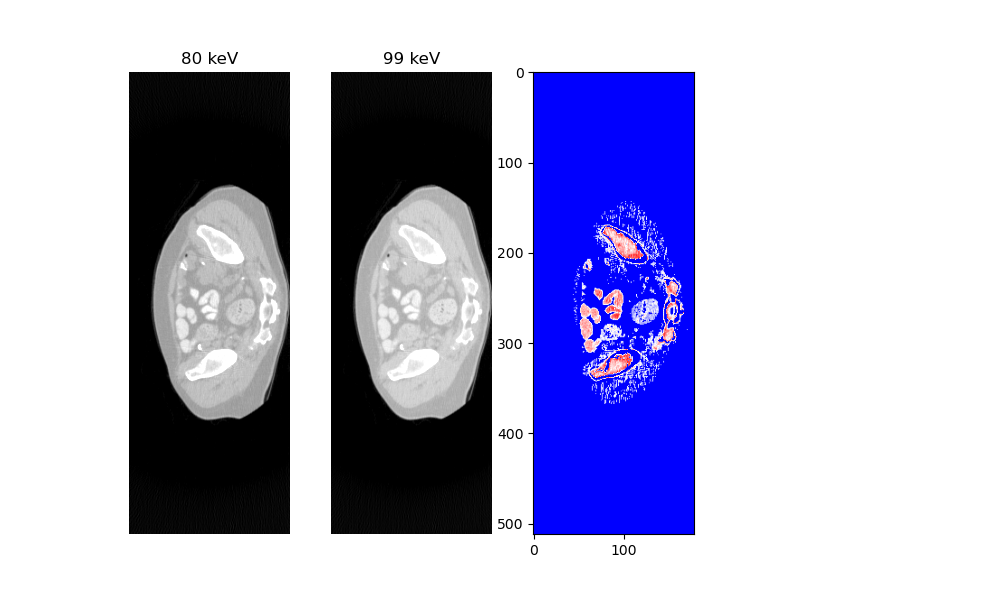

In [377]:
plt.figure(figsize=[10,6])
plt.subplot(141)
plt.imshow(np.flipud(phantom_img_80[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom_img_80[40],40),vmax=np.percentile(phantom_img_80[40],98))
plt.title('80 keV')
plt.axis('off')
plt.subplot(142)
plt.imshow(np.flipud(phantom_img_99[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom_img_99[40],40),vmax=np.percentile(phantom_img_99[40],98))
plt.title('99 keV')
plt.axis('off')
plt.subplot(143)
img_sub = phantom_img_99[40,:,:]-phantom_img_80[40,:,:]
img_sub[ phantom_img_80[40] < 0.02] = 0
img_sub[ phantom_img_80[40] > 0.028] = 0
plt.imshow(np.flipud(img_sub),cmap='bwr_r',aspect='equal')


## Second layer

In [135]:
phantom = patient_data.patient_phantom(nrrd_file, 1e10, reload=True, sim_num=sim_num, second_layer=True)

[2024-06-05 13:40:33,219] {patient_data.py:69} INFO - Reloading phantom
[2024-06-05 13:40:33,219] {patient_data.py:154} INFO - Found existing directory. Using mhd file Pelvis_Prostate_Patient_5_phantom.mhd
[2024-06-05 13:40:33,271] {patient_data.py:184} INFO - Phantom loaded from pickle file fastmc_1e10_10angles.pkl
[2024-06-05 13:40:33,303] {patient_data.py:190} INFO - Loading ggems files

[2024-06-05 13:40:33,303] {patient_data.py:214} INFO - Using the second detector layer ggems files
[2024-06-05 13:40:33,384] {patient_data.py:259} INFO - ggems files loaded
[2024-06-05 13:40:33,384] {patient_data.py:260} INFO -     Scatter files:
[2024-06-05 13:40:33,385] {patient_data.py:263} INFO -         /home/berbecolab/Software/gecco-master/gecco/data/user_phantoms/Pelvis_Prostate_Patient_5/fastmc_output/fastmc_0.00_2-scatter.mhd
[2024-06-05 13:40:33,385] {patient_data.py:265} INFO -           Shape:(360, 360)
[2024-06-05 13:40:33,385] {patient_data.py:263} INFO -         /home/berbecolab/Soft

In [136]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

# First layer filters
spectrum.filter('Cesium Iodide',0.6*0.71) # 71% fill factor
spectrum.filter('Si',1.1)

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,360,conv_on=False)

[2024-06-05 13:40:33,767] {patient_data.py:609} INFO - Making a list of angles
[2024-06-05 13:40:33,767] {patient_data.py:637} INFO - Detector matching specifications: CsI-784-micrometer
[2024-06-05 13:40:33,770] {ggems_simulate.py:204} INFO - Initializing filter /home/berbecolab/Software/gecco-master/gecco/data/bowties/half_fan_mm.dat
[2024-06-05 13:40:33,953] {ggems_simulate.py:581} INFO - Running Simulations
[2024-06-05 13:40:33,953] {ggems_simulate.py:609} INFO -     Simulating 10 keV
[2024-06-05 13:40:33,959] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight2 is 10.349854284535223
[2024-06-05 13:40:33,966] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight3 is 5.647085846302243
[2024-06-05 13:40:33,971] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight4 is 6.434291404998359
[2024-06-05 13:40:33,976] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for 

In [137]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.4,noise_weight=100) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
# phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

AttributeError: 'patient_phantom' object has no attribute 'img'

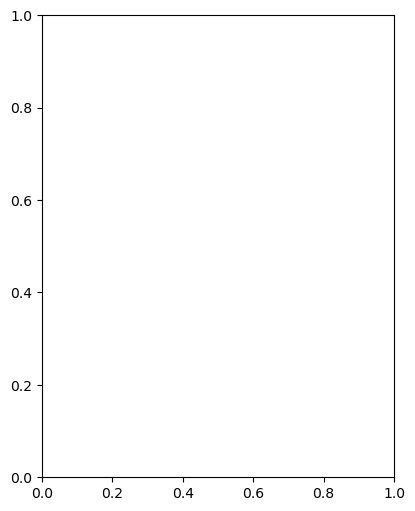

In [138]:
plt.figure(figsize=[10,6])
plt.subplot(121)
plt.imshow(np.flipud(phantom.img[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom.img[40],40),vmax=np.percentile(phantom.img[40],98))
# plt.title('GECCO CBCT')
plt.axis('off')
plt.subplot(122)
plt.imshow(np.flipud(phantom.density[31,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom.density[31],40),vmax=np.percentile(phantom.density[31],98))
# plt.title('Clinical CT')
plt.axis('off')
plt.tight_layout()

In [158]:
from gecco.utils import gecco_python_script_pelvis, write_run_all_script


output_dir = 'gecco_data'

output_dir_abs = os.path.join(os.getcwd(),output_dir)

for key,nrrd in nrrd_files.items():
    print(key + ' : ' + nrrd[0])

    test_file_name = nrrd[0].split('/')[-1].split('.')[0] + '_test.py'
    test_sim_dir = './test_gecco_scripts'
    sim_num = nrrd[3]

    gecco_python_script_pelvis(nrrd[0],os.path.join(test_sim_dir,test_file_name), 
                               output_dir_abs, sim_num, test=True)

# Combine the current working directory with the test_sim_dir
test_sim_dir_abs = os.path.join(os.getcwd(),test_sim_dir)
write_run_all_script(test_sim_dir_abs)

# Make the script executable
!chmod +x ./test_gecco_scripts/run_all.sh

0 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd
1 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd
2 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd
3 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd
4 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd
5 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd
6 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd
7 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd
[2024-06-05 14:10:59,330] {utils.py:1020} INFO - Script written to run all Python files in the directory


In [159]:
from gecco.utils import gecco_python_script_pelvis, write_run_all_script


output_dir = 'gecco_data'

output_dir_abs = os.path.join(os.getcwd(),output_dir)

for key,nrrd in nrrd_files.items():
    print(key + ' : ' + nrrd[0])

    test_file_name = nrrd[0].split('/')[-1].split('.')[0] + '.py'
    test_sim_dir = './gecco_scripts'
    sim_num = nrrd[3]

    gecco_python_script_pelvis(nrrd[0],os.path.join(test_sim_dir,test_file_name), 
                               output_dir_abs, sim_num, test=False)

# Combine the current working directory with the test_sim_dir
test_sim_dir_abs = os.path.join(os.getcwd(),test_sim_dir)
write_run_all_script(test_sim_dir_abs)

# Make the script executable
!chmod +x ./gecco_scripts/run_all.sh

0 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd
1 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd
2 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd
3 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd
4 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd
5 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd
6 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd
7 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd
[2024-06-05 15:19:52,467] {utils.py:1020} INFO - Script written to run all Python files in the directory


In [163]:
from gecco.utils import gecco_python_script_pelvis, write_run_all_script


output_dir = 'gecco_data_matlab'

output_dir_abs = os.path.join(os.getcwd(),output_dir)

for key,nrrd in nrrd_files.items():
    print(key + ' : ' + nrrd[0])

    test_file_name = nrrd[0].split('/')[-1].split('.')[0] + '.py'
    test_sim_dir = './gecco_scripts_matlab'
    sim_num = nrrd[3]

    gecco_python_script_pelvis(nrrd[0],os.path.join(test_sim_dir,test_file_name), 
                               output_dir_abs, sim_num, test=False,matlab=True)

# Combine the current working directory with the test_sim_dir
test_sim_dir_abs = os.path.join(os.getcwd(),test_sim_dir)
write_run_all_script(test_sim_dir_abs)

# Make the script executable
!chmod +x ./gecco_scripts_matlab/run_all.sh

0 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd
1 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd
2 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd
3 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd
4 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd
5 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd
6 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd
7 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd
[2024-06-05 15:35:21,400] {utils.py:1020} INFO - Script written to run all Python files in the directory
